------------------------------------
# Data Science in Cybersecurity


### Critical Evaluation and Reproduction of  
### Phishing Website Detection by Machine Learning Techniques

**Student:-** Karam Mahamed - 213029143




---------

## Project Overview

This notebook reproduces and critically evaluates the paper **“Phishing Detection Using Machine Learning Techniques.”**

The paper investigates the use of machine learning classifiers for detecting phishing websites. It compares several classification algorithms, including Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, K-Nearest Neighbors, Neural Networks, Gradient Boosting, and XGBoost.

The dataset contains 11,055 website samples represented by 30 engineered phishing-related features. Each sample is labeled as either phishing or legitimate.

The objectives of this notebook are:

1. Inspect and understand the provided dataset.
2. Analyze the quality and meaning of the extracted features.
3. Perform exploratory data analysis.
4. Reproduce selected machine learning experiments.
5. Compare multiple classification models.
6. Evaluate the models using cybersecurity-relevant metrics.
7. Analyze model errors, especially false positives and false negatives.
8. Determine whether the conclusions of the original paper are supported by the reproduced results.

inserting the ipnyp into the project folder and then checking that its in the right address.

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
%cd /content/drive/MyDrive/Cyber_phishing_final/

/content/drive/MyDrive/Cyber_phishing_final


In [46]:
!pwd
!ls

/content/drive/MyDrive/Cyber_phishing_final
data


In [47]:
!ls data

dataset.csv


#Imports & Configuration

In [48]:
# General libraries
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")

Libraries imported successfully.


#Part 1: Data Loading

The dataset is loaded from the CSV file provided in the GitHub repository linked by the selected paper.
it contains a identifier column, Thirty engineered phishing-related predictor features & One target column named `Result`

The original target encoding is:
- `-1` = phishing website
- `1` = legitimate website

At this stage, the original labels are preserved. Target transformation will be performed later during preprocessing.


In [49]:
# Dataset path
dataset_path = Path("data/dataset.csv")

if not dataset_path.exists():
    raise FileNotFoundError(
        "dataset.csv was not found. "
        "Make sure it is stored inside the data folder."
    )

data = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
display(data.head())

Dataset loaded successfully.


,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


Several column names in the original CSV contained spelling mistakes or duplicated words. These names were corrected only to improve readability and code quality.


In [50]:
# Rename malformed or inconsistent column names for readability
data = data.rename(columns={
    "having_IPhaving_IP_Address": "Having_IP_Address",
    "URLURL_Length": "URL_Length",
    "Shortining_Service": "Shortening_Service",
    "Domain_registeration_length": "Domain_Registration_Length",
    "popUpWidnow": "Popup_Window",
    "Iframe": "IFrame",
    "DNSRecord": "DNS_Record"
})

print("Column names cleaned successfully.")
print(data.columns.tolist())

Column names cleaned successfully.
['index', 'Having_IP_Address', 'URL_Length', 'Shortening_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_Registration_Length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'Popup_Window', 'IFrame', 'age_of_domain', 'DNS_Record', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


Now we try to get more info on the dataset like Dataset Size, General Dataset Information & Summary Statistics

In [51]:
number_of_rows, number_of_columns = data.shape

print(f"Dataset Shape: {data.shape}")
print(f"Number of rows: {number_of_rows}")
print(f"Number of columns: {number_of_columns}")
data.info()
summary_statistics = data.describe().T
display(summary_statistics)

Dataset Shape: (11055, 32)
Number of rows: 11055
Number of columns: 32
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   index                       11055 non-null  int64
 1   Having_IP_Address           11055 non-null  int64
 2   URL_Length                  11055 non-null  int64
 3   Shortening_Service          11055 non-null  int64
 4   having_At_Symbol            11055 non-null  int64
 5   double_slash_redirecting    11055 non-null  int64
 6   Prefix_Suffix               11055 non-null  int64
 7   having_Sub_Domain           11055 non-null  int64
 8   SSLfinal_State              11055 non-null  int64
 9   Domain_Registration_Length  11055 non-null  int64
 10  Favicon                     11055 non-null  int64
 11  port                        11055 non-null  int64
 12  HTTPS_token                 11055 non-null  i

,count,mean,std,min,25%,50%,75%,max
index,11055.0,5528.000000,3191.447947,1.0,2764.5,5528.0,8291.5,11055.0
Having_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
URL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
Shortening_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
Domain_Registration_Length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0


## Initial Dataset Interpretation
The dataset contains 11,055 observations and 32 columns.

All columns are stored as integer values. Most phishing indicators use the values `-1`, `0`, and `1`, which represent different states of a website feature.

## Feature and Column Inspection

In [52]:
column_summary = pd.DataFrame({
    "Column": data.columns,
    "Data Type": data.dtypes.astype(str).values,
    "Unique Values": data.nunique(dropna=False).values,
    "Missing Values": data.isna().sum().values
})

display(column_summary)

,Column,Data Type,Unique Values,Missing Values
0,index,int64,11055,0
1,Having_IP_Address,int64,2,0
2,URL_Length,int64,3,0
3,Shortening_Service,int64,2,0
4,having_At_Symbol,int64,2,0
5,double_slash_redirecting,int64,2,0
6,Prefix_Suffix,int64,2,0
7,having_Sub_Domain,int64,3,0
8,SSLfinal_State,int64,3,0
9,Domain_Registration_Length,int64,2,0


## Feature Types

Although pandas stores all columns as integers, most predictor variables should be interpreted as categorical or ordinal indicators rather than continuous measurements.

* Binary indicators usually contain `-1` and `1`.
* Some features contain `-1`, `0`, and `1`, representing multiple risk levels.
* The `Result` column is the binary target.

This distinction is important because numerical storage does not necessarily mean that arithmetic distance between values has a natural real-world meaning.

## Index Analysis

In [53]:
print("Pandas index type:", type(data.index).__name__)
print("Pandas index name:", data.index.name)
print("First five pandas index values:", data.index[:5].tolist())
print("Is pandas index unique?", data.index.is_unique)

print("\nCSV index column:")
print("First five values:", data["index"].head().tolist())
print("Is the CSV index column unique?", data["index"].is_unique)
print("Minimum value:", data["index"].min())
print("Maximum value:", data["index"].max())

Pandas index type: RangeIndex
Pandas index name: None
First five pandas index values: [0, 1, 2, 3, 4]
Is pandas index unique? True

CSV index column:
First five values: [1, 2, 3, 4, 5]
Is the CSV index column unique? True
Minimum value: 1
Maximum value: 11055


### Index Analysis

The DataFrame uses the default pandas `RangeIndex`, which begins at 0 and ends at 11054.

The CSV also contains a separate column named `index` that will be removed, whose values range from 1 to 11055. This column is only a row identifier and does not describe any property of the website.

## Missing Value Analysis

In [54]:
missing_value_summary = pd.DataFrame({
    "Missing Count": data.isna().sum(),
    "Missing Percentage": (data.isna().mean() * 100).round(2)
})

missing_value_summary = missing_value_summary.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing_value_summary)

total_missing_values = int(data.isna().sum().sum())
print("Total missing values:", total_missing_values)

,Missing Count,Missing Percentage
index,0,0.0
Having_IP_Address,0,0.0
URL_Length,0,0.0
Shortening_Service,0,0.0
having_At_Symbol,0,0.0
double_slash_redirecting,0,0.0
Prefix_Suffix,0,0.0
having_Sub_Domain,0,0.0
SSLfinal_State,0,0.0
Domain_Registration_Length,0,0.0


Total missing values: 0


No missing values were found in the published dataset.

Therefore, no imputation is required before model training.

However, the absence of missing values suggests that the dataset was already cleaned before publication. some websites may be offline, blocked, removed, or inaccessible when domain and webpage features are collected. These cases may have been removed or assigned predefined values, but the exact process is not fully documented.


## Temporal Analysis

In [55]:
temporal_keywords = [
    "date",
    "time",
    "timestamp",
    "year",
    "month",
    "day"
]

explicit_temporal_columns = [
    column
    for column in data.columns
    if any(keyword in column.lower() for keyword in temporal_keywords)
]

print("Explicit temporal columns:", explicit_temporal_columns)

time_related_features = [
    column
    for column in data.columns
    if column in ["age_of_domain", "Domain_Registration_Length"]
]

print("Time-related feature columns:", time_related_features)

Explicit temporal columns: []
Time-related feature columns: ['Domain_Registration_Length', 'age_of_domain']


The dataset does not contain an explicit collection date or timestamp for each sample.

The features `age_of_domain` and `Domain_Registration_Length` are related to time, but they describe domain properties rather than when each observation was collected.

Therefore samples cannot be ordered chronologically, A temporal train-test split cannot be performed, Concept drift cannot be measured and its not possible to test whether a model trained on older phishing websites generalizes to newer phishing techniques.

phishing attacks evolve over time, and a random split may provide more optimistic results than a future-based evaluation.

## Constant and Low-Information Features

In [56]:
unique_value_summary = pd.DataFrame({
    "Column": data.columns,
    "Unique Values": data.nunique(dropna=False).values
}).sort_values(by="Unique Values")

display(unique_value_summary)

constant_columns = [
    column
    for column in data.columns
    if data[column].nunique(dropna=False) == 1
]

print("Constant columns:", constant_columns)

,Column,Unique Values
1,Having_IP_Address,2
3,Shortening_Service,2
5,double_slash_redirecting,2
4,having_At_Symbol,2
6,Prefix_Suffix,2
11,port,2
10,Favicon,2
9,Domain_Registration_Length,2
13,Request_URL,2
12,HTTPS_token,2


Constant columns: []


A constant feature contains the same value for every observation. Such a feature has zero variance and cannot help distinguish phishing websites from legitimate websites. No constant columns were found in the dataset Therefore, no feature needs to be removed for having a single value.

## Duplicate Row Analysis

In [57]:
duplicate_rows = int(data.duplicated().sum())
duplicate_percentage = duplicate_rows / len(data) * 100

print("Exact duplicate rows:", duplicate_rows)
print(f"Duplicate row percentage: {duplicate_percentage:.2f}%")

Exact duplicate rows: 0
Duplicate row percentage: 0.00%


In [58]:
feature_columns = [
    column
    for column in data.columns
    if column not in ["index", "Result"]
]

repeated_pattern_mask = data.duplicated(
    subset=feature_columns,keep=False)

repeated_pattern_rows = int(repeated_pattern_mask.sum())

distinct_repeated_patterns = (
    data.loc[repeated_pattern_mask, feature_columns]
    .drop_duplicates()
    .shape[0]
)

print(
    "Rows belonging to repeated feature patterns:",
    repeated_pattern_rows
)

print(
    "Distinct repeated feature patterns:",
    distinct_repeated_patterns
)

feature_pattern_counts = (
    data
    .groupby(feature_columns, dropna=False)
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

print("\nMost common repeated feature patterns:")
display(feature_pattern_counts.head(10))

Rows belonging to repeated feature patterns: 7884
Distinct repeated feature patterns: 2614

Most common repeated feature patterns:


,Having_IP_Address,URL_Length,Shortening_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_Registration_Length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,Popup_Window,IFrame,age_of_domain,DNS_Record,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Count
4667,1,-1,1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,1,1,1,-1,1,0,1,25
3540,1,-1,1,1,1,-1,-1,1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,1,1,1,-1,1,0,1,24
4786,1,-1,1,1,1,-1,1,1,-1,1,1,1,1,1,1,-1,1,1,0,1,1,1,1,1,1,1,-1,1,0,1,24
4759,1,-1,1,1,1,-1,1,1,-1,1,1,1,1,1,0,-1,1,1,0,1,1,1,1,1,1,1,-1,1,0,1,22
4216,1,-1,1,1,1,-1,0,1,-1,1,1,1,1,0,1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,0,1,16
4002,1,-1,1,1,1,-1,0,0,-1,1,1,1,1,-1,0,-1,1,1,0,1,1,1,1,1,1,-1,-1,1,0,1,16
4713,1,-1,1,1,1,-1,1,1,-1,1,1,1,1,0,1,-1,1,1,0,1,1,1,1,1,1,1,-1,1,0,1,15
4666,1,-1,1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,1,1,0,-1,1,0,1,13
3967,1,-1,1,1,1,-1,0,0,-1,1,1,1,-1,-1,-1,-1,1,1,0,1,1,1,1,1,-1,-1,-1,1,1,1,13
4213,1,-1,1,1,1,-1,0,1,-1,1,1,1,1,0,1,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,1,1,13


Repeated feature patterns are common in this dataset because different websites can share the same feature representation. If identical patterns appear in both the training and testing sets, the evaluation may become slightly optimistic.

In [59]:
labels_per_pattern = (
    data
    .groupby(feature_columns, dropna=False)["Result"]
    .nunique()
)

conflicting_patterns = labels_per_pattern[
    labels_per_pattern > 1
]

print(
    "Feature patterns with conflicting labels:",
    len(conflicting_patterns)
)

if len(conflicting_patterns) > 0:

    conflicting_pattern_features = (
        conflicting_patterns
        .reset_index()[feature_columns]
    )

    conflicting_samples = (
        data
        .merge(
            conflicting_pattern_features,
            on=feature_columns,
            how="inner"
        )
        .sort_values(feature_columns)
    )

    print("\nExamples of conflicting feature patterns:")
    display(conflicting_samples.head(20))

else:
    print("No conflicting labels were found.")

Feature patterns with conflicting labels: 64

Examples of conflicting feature patterns:


,index,Having_IP_Address,URL_Length,Shortening_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_Registration_Length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,Popup_Window,IFrame,age_of_domain,DNS_Record,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
224,6221,-1,-1,1,1,1,-1,-1,1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,-1,1,0,1,1,0,1,1
229,6362,-1,-1,1,1,1,-1,-1,1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,-1,1,0,1,1,0,1,-1
264,7844,-1,-1,1,1,1,-1,-1,1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,-1,1,0,1,1,0,1,1
208,5571,-1,-1,1,1,1,-1,0,-1,1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,1,1,-1
212,5769,-1,-1,1,1,1,-1,0,-1,1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,1,1,-1
227,6310,-1,-1,1,1,1,-1,0,-1,1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,1,1,1
234,6620,-1,-1,1,1,1,-1,0,-1,1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,1,1,1
237,6795,-1,-1,1,1,1,-1,0,-1,1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,1,1,1
243,6970,-1,-1,1,1,1,-1,0,-1,1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,1,1,1
244,6977,-1,-1,1,1,1,-1,0,-1,1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,1,1,-1


Conflicting feature patterns represent identical inputs that belong to different classes. These cases are important because no classifier can perfectly separate samples that have the same features but different labels.
were checked twice once using the complete dataset and he second after excluding the unique `index` column
The last is more meaningful because the identifier column can make otherwise identical samples appear different.

Repeated samples may cause data leakage if identical feature vectors appear in both the training and testing sets. This can produce overly optimistic model performance because the model may effectively see the same observation during training.

## Detect Identical Feature Columns

In [60]:
predictor_columns = [
    column
    for column in data.columns
    if column not in ["index", "Result"]
]

duplicated_feature_pairs = []

for first_position, first_feature in enumerate(predictor_columns):
    for second_feature in predictor_columns[first_position + 1:]:
        if data[first_feature].equals(data[second_feature]):
            duplicated_feature_pairs.append(
                (first_feature, second_feature)
            )

print("Exactly duplicated feature pairs:")
print(duplicated_feature_pairs)

Exactly duplicated feature pairs:
[]


Duplicate features add no new information and may increase model complexity, distort coefficient-based models and Create unnecessary redundancy.

Exact duplicate columns were checked directly. Strong but non identical redundancy will be investigated later using correlation analysis.

## Data Quality Summary

In [61]:
data_quality_summary = pd.DataFrame({
    "Property": [
        "Number of rows",
        "Number of columns",
        "Predictor features",
        "Missing values",
        "Constant columns",
        "Exact duplicate rows",
        "Duplicate samples without index",
        "Exactly duplicated feature pairs",
        "Explicit temporal columns"
    ],
    "Value": [
        data.shape[0],
        data.shape[1],
        len(predictor_columns),
        total_missing_values,
        len(constant_columns),
        duplicate_rows,
        int(data.drop(columns=["index"]).duplicated().sum()),
        len(duplicated_feature_pairs),
        len(explicit_temporal_columns)
    ]
})

display(data_quality_summary)

,Property,Value
0,Number of rows,11055
1,Number of columns,32
2,Predictor features,30
3,Missing values,0
4,Constant columns,0
5,Exact duplicate rows,0
6,Duplicate samples without index,5206
7,Exactly duplicated feature pairs,0
8,Explicit temporal columns,0


### Data Loading and Inspection Summary

The dataset was loaded successfully the main findings from the inspection stage are:
- All columns are stored as integers.
- Most predictors use categorical values encoded as `-1`, `0`, and `1`.
- No missing values were found.
- No explicit sample timestamps are available.
- Constant features were checked.
- Duplicate rows and duplicated feature columns were investigated.
- The published data appears to have already undergone preprocessing before release.

The dataset is suitable for further exploratory analysis, but the lack of timestamps and incomplete documentation of preprocessing should be considered.

#Part 2: Exploratory Data Analysis (EDA)
This section explores the dataset before training the models. The goal is to understand the class distribution, feature behavior, possible outliers, and relationships between features.

## Class Distribution

In [62]:
class_counts = data["Result"].value_counts().sort_index()

print(class_counts)

class_percentages = (
    data["Result"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

print("\nPercentages:")
print(class_percentages)

Result
-1    4898
 1    6157
Name: count, dtype: int64

Percentages:
Result
-1    44.31
 1    55.69
Name: proportion, dtype: float64


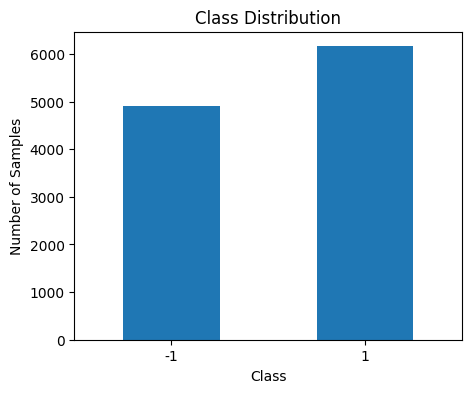

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.xticks(rotation=0)

plt.show()

The dataset is almost balanced between phishing and legitimate websites. This is useful for training because the models are less likely to favor one class. In practice phishing websites are much less common than legitimate ones.

##Feature Distributions

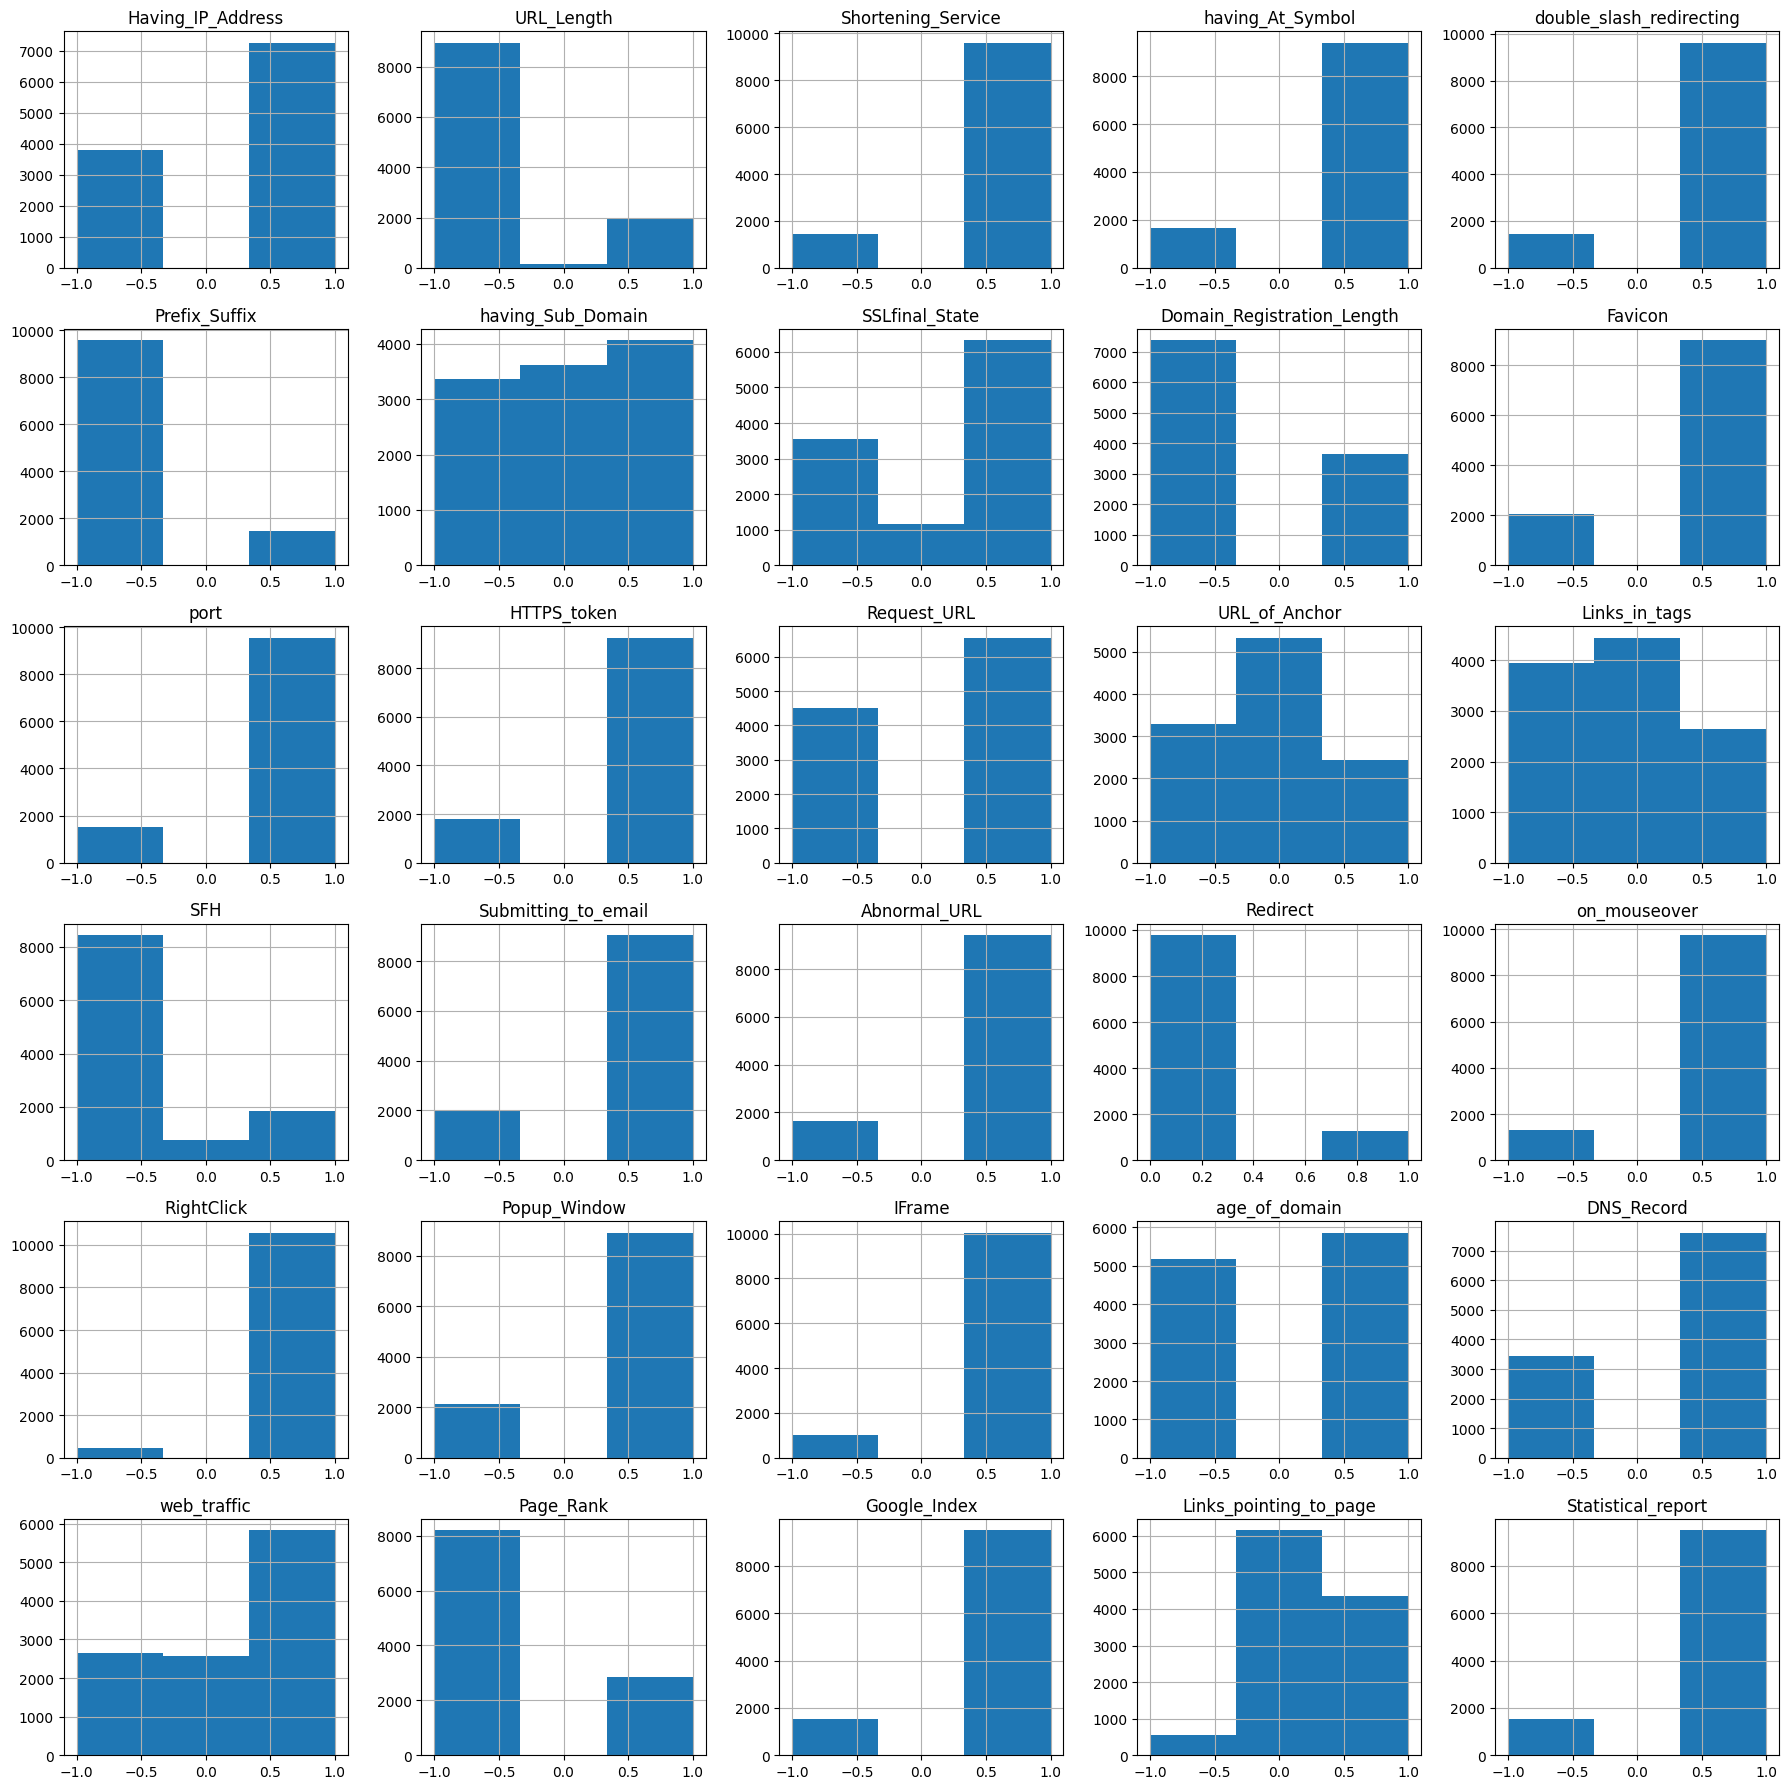

In [64]:
predictor_columns = data.columns.drop(["index", "Result"])

data[predictor_columns].hist(
    figsize=(18,18),
    bins=3
)
plt.tight_layout()
plt.show()

Most features contain only the values -1, 0, and 1, which shows that they are encoded categorical features rather than continuous variables.

## Outlier Analysis

In [65]:
summary = data[predictor_columns].describe().T
display(summary)

,count,mean,std,min,25%,50%,75%,max
Having_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
URL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
Shortening_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
Domain_Registration_Length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11055.0,0.628584,0.777777,-1.0,1.0,1.0,1.0,1.0


The features are encoded using a small set of discrete values (-1, 0, and 1). Therefore traditional numerical outlier detection is not appropriate for this dataset.

##GroupBy Analysis

In [66]:
grouped = (data.groupby("Result").mean())
display(grouped)

,index,Having_IP_Address,URL_Length,Shortening_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_Registration_Length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,Popup_Window,IFrame,age_of_domain,DNS_Record,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report
Result,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
-1,5524.501837,0.213557,-0.682523,0.790118,0.658228,0.770519,-1.000000,-0.209473,-0.479788,-0.098408,0.628828,0.700286,0.708044,-0.092283,-0.632095,-0.330747,-0.784198,0.619845,0.753369,0.122907,0.731727,0.908126,0.613312,0.81911,-0.074724,0.298489,-0.033891,-0.586362,0.621478,0.323193,0.657411
1,5530.782849,0.393536,-0.593958,0.697905,0.734286,0.718369,-0.524119,0.281468,0.832223,-0.526393,0.628390,0.750528,0.648855,0.408803,0.365438,0.050999,-0.445834,0.648205,0.667046,0.109956,0.786260,0.918467,0.613448,0.81517,0.169401,0.439662,0.542797,-0.401981,0.801202,0.360565,0.769043


The average value of each feature was calculated separately for phishing and legitimate websites. Large differences may indicate features that are useful for classification.

## Correlation Analysis

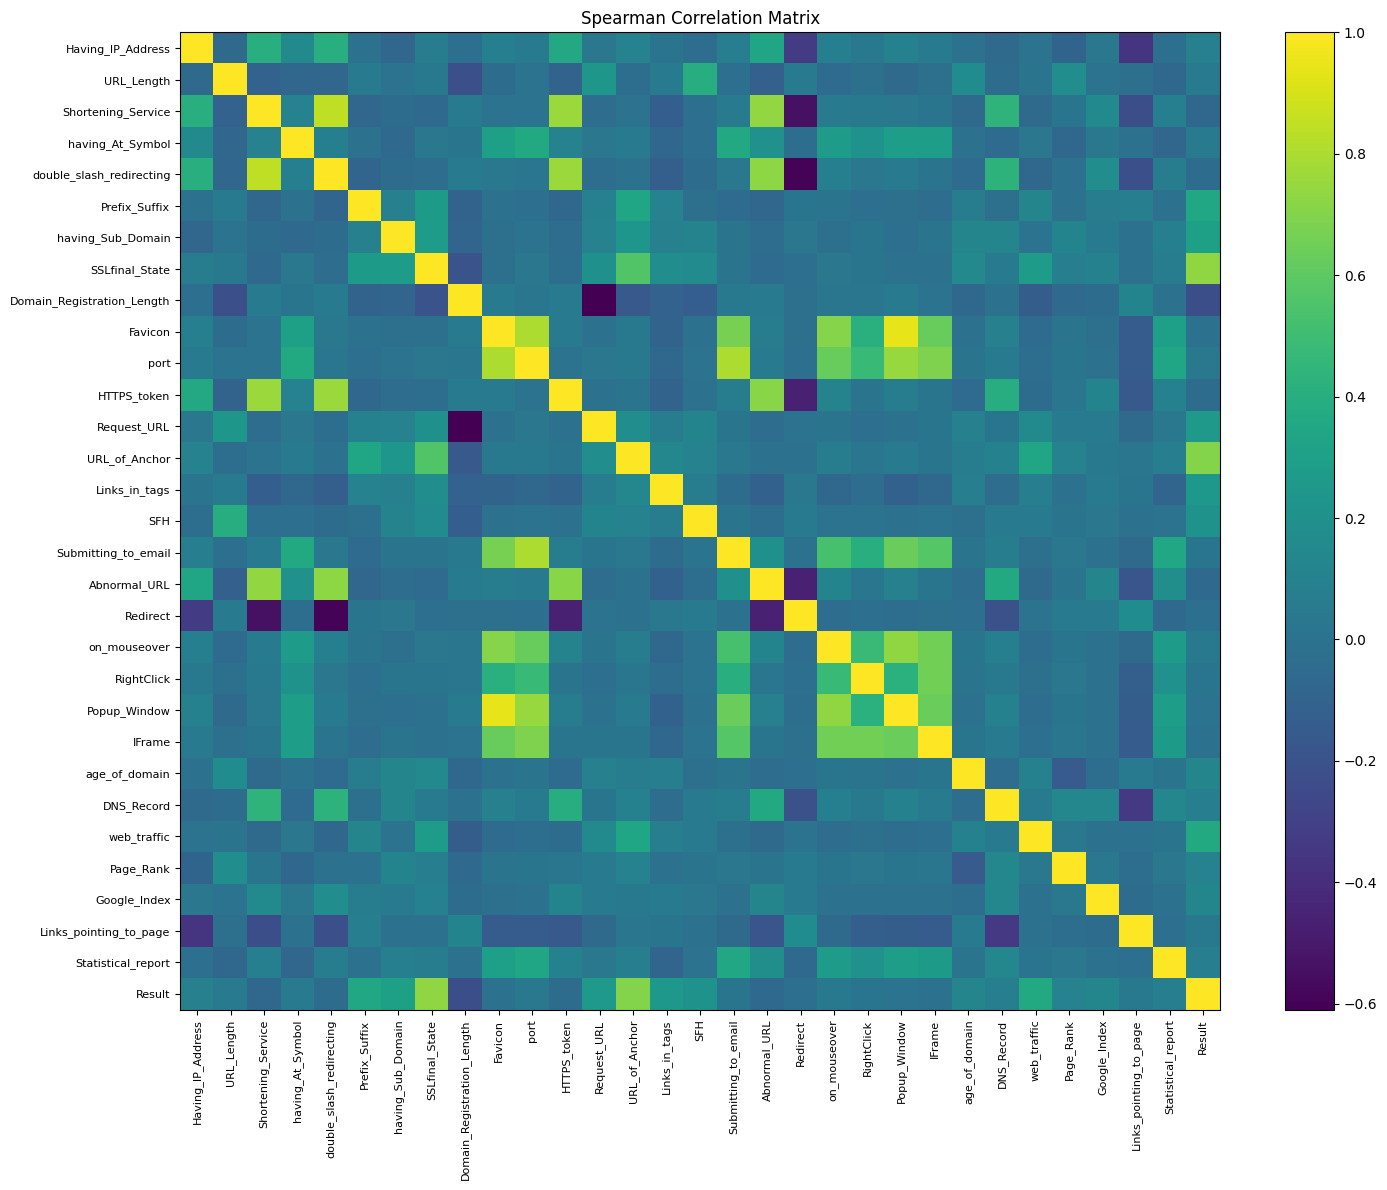

In [67]:
correlation = data.drop(columns=["index"]).corr(method="spearman")
plt.figure(figsize=(15,12))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns,
    fontsize=8
)

plt.title("Spearman Correlation Matrix")

plt.tight_layout()

plt.show()

Spearman correlation was used because the features are ordinal and encoded using -1, 0, and 1. Unlike Pearson correlation, Spearman measures monotonic relationships and is more suitable for this type of data.
Highly correlated features may contain redundant information and could be considered for feature selection.

## Strong Correlations

In [68]:
corr_pairs = (correlation.abs().unstack().sort_values(ascending=False))
corr_pairs = corr_pairs[corr_pairs < 1]
display(corr_pairs.head(20))

,,0
Popup_Window,Favicon,0.939633
Favicon,Popup_Window,0.939633
double_slash_redirecting,Shortening_Service,0.842796
Shortening_Service,double_slash_redirecting,0.842796
Favicon,port,0.803834
port,Favicon,0.803834
Submitting_to_email,port,0.799088
port,Submitting_to_email,0.799088
HTTPS_token,double_slash_redirecting,0.760799
double_slash_redirecting,HTTPS_token,0.760799


The strongest correlations were inspected to identify possible redundancy between features. Highly correlated features may provide similar information to the model.

##Target Correlation

In [69]:
target_corr = (correlation["Result"].sort_values(ascending=False))
display(target_corr)

,Result
Result,1.000000
SSLfinal_State,0.735814
URL_of_Anchor,0.701207
web_traffic,0.365118
Prefix_Suffix,0.348606
having_Sub_Domain,0.304692
Request_URL,0.253372
Links_in_tags,0.250711
SFH,0.219190
Google_Index,0.128950


Features with higher correlation to the target are expected to have a stronger influence on phishing detection and may contribute more to the classification models.

##Crosstab Analysis

In [70]:
pd.crosstab(data["Having_IP_Address"],data["Result"],margins=True)


Result,-1,1,All
Having_IP_Address,,,
-1,1926,1867,3793
1,2972,4290,7262
All,4898,6157,11055


In [71]:
pd.crosstab(data["SSLfinal_State"],data["Result"],margins=True)

Result,-1,1,All
SSLfinal_State,,,
-1,3051,506,3557
0,1146,21,1167
1,701,5630,6331
All,4898,6157,11055


Crosstab tables show how feature values are distributed across phishing and legitimate websites. This helps identify features that separate the two classes.

---------
##EDA Summary
The dataset is balanced and contains mostly categorical features encoded as -1, 0, and 1. No numerical outlier treatment is required. Spearman correlation is appropriate for this dataset and helps identify redundant features and features that are strongly related to the target.

#Part 3: Feature Engineering
This section prepares the dataset for model training. It includes removing irrelevant features, preparing the target variable, splitting the data, and scaling features when required.

## Remove Irrelevant Features

In [72]:
X = data.drop(columns=["index", "Result"])
y = data["Result"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (11055, 30)
Target shape: (11055,)


##Target Analysis

In [73]:
print(y.value_counts().sort_index())

Result
-1    4898
 1    6157
Name: count, dtype: int64


The original dataset uses:

- **-1** = Phishing website
- **1** = Legitimate website

The original encoding is kept to remain consistent with the paper.

##Train-Test Split

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (8844, 30)
Testing set : (2211, 30)


The dataset was divided into 80% training data and 20% testing data. Stratified sampling was used to preserve the class distribution in both sets.

### Feature-Pattern Overlap Between Training and Test Sets

The random split was checked for identical feature patterns in both sets. If a test pattern already appears in training, the reported performance may be optimistic.

In [75]:
# Create comparable row patterns for the training and testing sets
train_pattern_index = pd.MultiIndex.from_frame(
    X_train.reset_index(drop=True)
)

test_pattern_index = pd.MultiIndex.from_frame(
    X_test.reset_index(drop=True)
)

test_overlap_mask = test_pattern_index.isin(
    train_pattern_index
)

overlapping_test_rows = int(test_overlap_mask.sum())

overlap_percentage = (
    overlapping_test_rows / len(X_test) * 100
)

print(
    "Test rows whose feature pattern appears in training:",
    overlapping_test_rows
)

print(
    f"Percentage of overlapping test rows: "
    f"{overlap_percentage:.2f}%"
)

Test rows whose feature pattern appears in training: 1455
Percentage of overlapping test rows: 65.81%


Some test samples have the same feature pattern as samples in the training set.

In [76]:
distinct_overlapping_patterns = (
    X_test
    .reset_index(drop=True)
    .loc[test_overlap_mask]
    .drop_duplicates()
)

print(
    "Distinct overlapping feature patterns:",
    len(distinct_overlapping_patterns)
)

display(distinct_overlapping_patterns.head(10))

Distinct overlapping feature patterns: 1173


,Having_IP_Address,URL_Length,Shortening_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_Registration_Length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,Popup_Window,IFrame,age_of_domain,DNS_Record,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report
2,1,1,1,1,1,1,1,1,-1,-1,-1,1,1,1,1,1,-1,1,0,-1,1,-1,-1,1,-1,1,1,1,1,-1
3,1,-1,1,1,1,-1,0,0,1,1,1,1,-1,-1,-1,-1,1,1,0,1,1,1,1,1,-1,0,-1,1,1,1
7,1,-1,1,1,1,1,1,1,1,1,1,1,-1,1,1,-1,1,1,0,1,1,1,1,1,1,1,-1,1,0,1
10,-1,-1,-1,1,-1,1,-1,1,-1,1,1,-1,1,1,-1,-1,1,-1,1,1,1,1,1,1,-1,1,-1,1,1,1
12,1,-1,1,1,1,-1,1,1,-1,1,1,1,1,1,0,-1,1,1,0,1,1,1,1,1,-1,-1,-1,1,1,1
14,1,1,1,1,1,-1,0,1,-1,1,1,1,1,0,-1,1,1,1,0,1,1,1,1,-1,1,1,-1,1,0,1
15,1,1,1,1,1,-1,-1,1,-1,1,1,1,1,0,0,1,1,1,0,1,1,1,1,1,1,1,-1,1,0,1
16,1,-1,1,1,1,-1,1,1,-1,1,1,1,1,1,0,-1,1,1,0,1,1,1,1,-1,1,1,1,1,0,1
17,1,-1,1,1,1,-1,-1,-1,-1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1
19,1,1,1,1,1,1,-1,1,-1,1,1,1,1,1,0,1,1,1,0,1,1,1,1,-1,-1,1,-1,1,1,1


Grouped validation is added later to keep identical feature patterns in the same fold and avoid this overlap.

##Feature Scaling

In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Standardization was applied for models that are sensitive to feature scales, like Logistic Regression and Support Vector Machines. on the other hand tree-based models are not affected by feature scaling, so they will use the original feature values.

##Feature Selection

In [78]:
print("Number of predictor features:", X.shape[1])
print(X.columns.tolist())

Number of predictor features: 30
['Having_IP_Address', 'URL_Length', 'Shortening_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_Registration_Length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'Popup_Window', 'IFrame', 'age_of_domain', 'DNS_Record', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


No features were removed before training. All 30 phishing-related features were kept to reproduce the original work as closely as possible.

## Feature-Pattern Groups

Each unique 30-feature vector is assigned a group number. These groups will be used to prevent identical patterns from appearing in both training and validation folds.

In [79]:
# Assign one group ID to every unique feature pattern
pattern_groups = pd.MultiIndex.from_frame(X).factorize()[0]

print("Number of samples:", len(X))
print(
    "Number of unique feature patterns:",
    len(np.unique(pattern_groups))
)

Number of samples: 11055
Number of unique feature patterns: 5785


##Feature Engineering Summary
The dataset required only minimal preprocessing. The identifier column was removed, the target variable was separated, the data was split into training and testing sets, and standardized features were prepared for models that require scaling.

#Part 4: Model Training
Four machine learning classifiers were trained and compared:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

The same train-test split was used for all models to ensure a fair comparison.

##Train Logistic Regression

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
logistic_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


its a classification algorithm standardized features were used because the model is sensitive to feature scaling.

##Train Decision Tree
Decision Trees split the data into decision rules based on feature values.

In [81]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


##Train Random Forest
Random Forest combines many decision trees to improve accuracy and reduce overfitting.

In [82]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


##Train XGBoost

In [83]:
!pip install xgboost

In [84]:
from xgboost import XGBClassifier

# Convert labels only for XGBoost
y_train_xgb = y_train.replace({
    -1: 0,
     1: 1
})

y_test_xgb = y_test.replace({
    -1: 0,
     1: 1
})

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train_xgb)

print("XGBoost trained successfully.")

XGBoost trained successfully.


##Model Summary
All four models were trained successfully. Logistic Regression used standardized features, while the tree-based models used the original feature values.

In [85]:
trained_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "XGBoost": xgb_model
}

print("Models trained:")

for model in trained_models:
    print("-", model)

Models trained:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


#Part 5: Model Evaluation
The trained models are evaluated using several classification metrics. Since phishing detection is a cybersecurity problem, relying only on accuracy is not sufficient. Metrics such as Precision and the Confusion Matrix provide a more complete evaluation.

##Prediction & Import Metrics

In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

logistic_pred = logistic_model.predict(X_test_scaled)
decision_tree_pred = decision_tree.predict(X_test)
random_forest_pred = random_forest.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
xgb_pred = np.where(xgb_pred == 0, -1, 1)

## Evaluation Function

In [87]:
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=-1)
    recall = recall_score(y_true, y_pred, pos_label=-1)
    f1 = f1_score(y_true, y_pred, pos_label=-1)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"MCC      : {mcc:.4f}")

## Evaluate All Models

In [88]:
evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred
)

evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    random_forest_pred
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)


Logistic Regression
----------------------------------------
Accuracy : 0.9285
Precision: 0.9354
Recall   : 0.9010
F1 Score : 0.9179
MCC      : 0.8551

Decision Tree
----------------------------------------
Accuracy : 0.9711
Precision: 0.9722
Recall   : 0.9622
F1 Score : 0.9672
MCC      : 0.9413

Random Forest
----------------------------------------
Accuracy : 0.9742
Precision: 0.9802
Recall   : 0.9612
F1 Score : 0.9706
MCC      : 0.9478

XGBoost
----------------------------------------
Accuracy : 0.9738
Precision: 0.9802
Recall   : 0.9602
F1 Score : 0.9701
MCC      : 0.9469


## ROC-AUC

In [89]:
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:,1]

decision_tree_prob = decision_tree.predict_proba(X_test)[:,1]

random_forest_prob = random_forest.predict_proba(X_test)[:,1]

xgb_prob = xgb_model.predict_proba(X_test)[:,1]
#labels conversion
y_test_binary = y_test.replace({-1:0,1:1})

print("ROC-AUC Scores\n")

print("Logistic Regression:",roc_auc_score(y_test_binary,logistic_prob))

print("Decision Tree:",roc_auc_score( y_test_binary,decision_tree_prob))

print("Random Forest:",roc_auc_score(y_test_binary,random_forest_prob))

print("XGBoost:",roc_auc_score(y_test_binary,xgb_prob))

ROC-AUC Scores

Logistic Regression: 0.9808024834629221
Decision Tree: 0.9804522621396243
Random Forest: 0.9976993153069514
XGBoost: 0.997463485800494


##Comparison Table
The models were compared using the same testing dataset and evaluation metrics. This allows a fair comparison of their performance on the phishing detection task.

In [90]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC"
])

models = [
    ("Logistic Regression", logistic_pred),
    ("Decision Tree", decision_tree_pred),
    ("Random Forest", random_forest_pred),
    ("XGBoost", xgb_pred)
]

for name, pred in models:

    results.loc[len(results)] = [
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, pos_label=-1),
        recall_score(y_test, pred, pos_label=-1),
        f1_score(y_test, pred, pos_label=-1),
        matthews_corrcoef(y_test, pred)
    ]

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1,MCC
0,Logistic Regression,0.9285,0.9354,0.9010,0.9179,0.8551
1,Decision Tree,0.9711,0.9722,0.9622,0.9672,0.9413
2,Random Forest,0.9742,0.9802,0.9612,0.9706,0.9478
3,XGBoost,0.9738,0.9802,0.9602,0.9701,0.9469


##Confusion Matrices

> Add blockquote



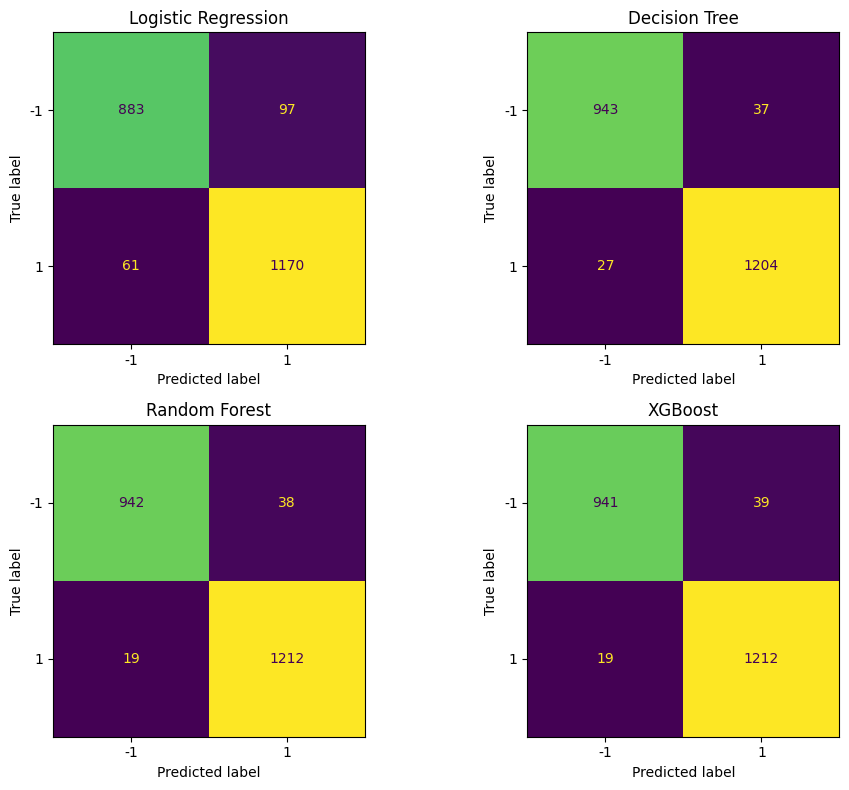

In [91]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

predictions = [
    logistic_pred,
    decision_tree_pred,
    random_forest_pred,
    xgb_pred
]

titles = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

for ax, pred, title in zip(axes.ravel(), predictions, titles):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        ax=ax,
        colorbar=False
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()

### Cross-Validation

The original paper used 10-fold cross-validation. I added both normal stratified cross-validation and grouped cross-validation based on identical feature patterns.

In [92]:
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedGroupKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer
cv_scoring = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        pos_label=-1,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        pos_label=-1,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        pos_label=-1,
        zero_division=0
    ),

    "mcc": make_scorer(
        matthews_corrcoef
    )
}

Logistic Regression is placed inside a pipeline so scaling is fitted separately inside every fold. This avoids preprocessing leakage.

In [93]:
cv_models = {
    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

Stratification keeps approximately the same phishing-to-legitimate ratio in every fold.

In [94]:
standard_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

standard_cv_results = []

for model_name, model in cv_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=standard_cv,
        scoring=cv_scoring,
        n_jobs=-1
    )

    standard_cv_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "MCC": scores["test_mcc"].mean()
    })

standard_cv_table = pd.DataFrame(
    standard_cv_results
)

display(standard_cv_table.round(4))

,Model,Accuracy,Precision,Recall,F1,MCC
0,Logistic Regression,0.9272,0.9291,0.9049,0.9167,0.8525
1,Decision Tree,0.9639,0.9633,0.9551,0.9591,0.9269
2,Random Forest,0.9721,0.9766,0.9602,0.9683,0.9436


Identical feature patterns are kept in the same fold. This prevents the same pattern from appearing in both training and validation data.

In [95]:
grouped_cv = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

grouped_cv_results = []

for model_name, model in cv_models.items():

    scores = cross_validate(
        model,
        X,
        y,
        groups=pattern_groups,
        cv=grouped_cv,
        scoring=cv_scoring,
        n_jobs=-1
    )

    grouped_cv_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "MCC": scores["test_mcc"].mean()
    })

grouped_cv_table = pd.DataFrame(
    grouped_cv_results
)

display(grouped_cv_table.round(4))

,Model,Accuracy,Precision,Recall,F1,MCC
0,Logistic Regression,0.9260,0.9277,0.9036,0.9153,0.8499
1,Decision Tree,0.9289,0.9065,0.9363,0.9210,0.8567
2,Random Forest,0.9541,0.9518,0.9447,0.9482,0.9070


Grouped cross-validation is the stricter evaluation because it measures performance on feature patterns that were not present during training.

In [96]:
cv_comparison = standard_cv_table.merge(
    grouped_cv_table,
    on="Model",
    suffixes=("_Standard", "_Grouped")
)

display(cv_comparison.round(4))
accuracy_comparison = cv_comparison[[
    "Model",
    "Accuracy_Standard",
    "Accuracy_Grouped"
]].copy()

accuracy_comparison["Accuracy Difference"] = (
    accuracy_comparison["Accuracy_Standard"]
    - accuracy_comparison["Accuracy_Grouped"]
)

display(accuracy_comparison.round(4))

,Model,Accuracy_Standard,Precision_Standard,Recall_Standard,F1_Standard,MCC_Standard,Accuracy_Grouped,Precision_Grouped,Recall_Grouped,F1_Grouped,MCC_Grouped
0,Logistic Regression,0.9272,0.9291,0.9049,0.9167,0.8525,0.9260,0.9277,0.9036,0.9153,0.8499
1,Decision Tree,0.9639,0.9633,0.9551,0.9591,0.9269,0.9289,0.9065,0.9363,0.9210,0.8567
2,Random Forest,0.9721,0.9766,0.9602,0.9683,0.9436,0.9541,0.9518,0.9447,0.9482,0.9070


,Model,Accuracy_Standard,Accuracy_Grouped,Accuracy Difference
0,Logistic Regression,0.9272,0.9260,0.0012
1,Decision Tree,0.9639,0.9289,0.0350
2,Random Forest,0.9721,0.9541,0.0180


A lower grouped score would show that repeated feature patterns increased the standard evaluation result. The grouped result is therefore a more conservative estimate of generalization.

###XGBoost cross-validation
XGBoost requires labels encoded as 0 and 1. For this evaluation, phishing is mapped to 1 and legitimate is mapped to 0.

In [97]:
y_xgb_cv = y.map({
    -1: 1,  # phishing
     1: 0   # legitimate
})

xgb_cv_scoring = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    ),

    "mcc": make_scorer(
        matthews_corrcoef
    )
}

In [98]:
xgb_cv_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_standard_scores = cross_validate(
    xgb_cv_model,
    X,
    y_xgb_cv,
    cv=standard_cv,
    scoring=xgb_cv_scoring,
    n_jobs=-1
)

xgb_grouped_scores = cross_validate(
    xgb_cv_model,
    X,
    y_xgb_cv,
    groups=pattern_groups,
    cv=grouped_cv,
    scoring=xgb_cv_scoring,
    n_jobs=-1
)

In [99]:
xgb_cv_summary = pd.DataFrame({
    "Validation": [
        "Standard 10-Fold",
        "Grouped 10-Fold"
    ],

    "Accuracy": [
        xgb_standard_scores["test_accuracy"].mean(),
        xgb_grouped_scores["test_accuracy"].mean()
    ],

    "Precision": [
        xgb_standard_scores["test_precision"].mean(),
        xgb_grouped_scores["test_precision"].mean()
    ],

    "Recall": [
        xgb_standard_scores["test_recall"].mean(),
        xgb_grouped_scores["test_recall"].mean()
    ],

    "F1": [
        xgb_standard_scores["test_f1"].mean(),
        xgb_grouped_scores["test_f1"].mean()
    ],

    "MCC": [
        xgb_standard_scores["test_mcc"].mean(),
        xgb_grouped_scores["test_mcc"].mean()
    ]
})

display(xgb_cv_summary.round(4))

,Validation,Accuracy,Precision,Recall,F1,MCC
0,Standard 10-Fold,0.9699,0.9726,0.9592,0.9658,0.9390
1,Grouped 10-Fold,0.9581,0.9538,0.9521,0.9528,0.9152


The grouped cross-validation produced slightly lower scores than the standard 10-fold cross-validation. This is expected because identical feature patterns were kept in the same fold, preventing them from appearing in both the training and validation sets.

Despite the small decrease in performance, the model still achieved high accuracy. This suggests that the classifier generalizes well even under a stricter evaluation protocol, and that repeated feature patterns had only a limited effect on the original performance estimates.

#Part 6: Error Analysis
This section analyzes the mistakes made by the trained models and discusses their impact in a phishing detection system.

##Compare Incorrect Predictions

In [100]:
error_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Incorrect Predictions": [
        (y_test != logistic_pred).sum(),
        (y_test != decision_tree_pred).sum(),
        (y_test != random_forest_pred).sum(),
        (y_test != xgb_pred).sum()
    ]
})

display(error_summary)

,Model,Incorrect Predictions
0,Logistic Regression,158
1,Decision Tree,64
2,Random Forest,57
3,XGBoost,58


as we see logistic regression made the most icorrect predictions while Random forst preformed the best & made the lesser mistakes between it and the other models.
The table above shows the number of incorrect predictions made by each model. Fewer errors generally indicate better classification performance.

##Inspect Misclassified Samples
using the best model which is as seen random forest

In [101]:
misclassified = X_test.copy()

misclassified["True_Label"] = y_test.values
misclassified["Predicted_Label"] = random_forest_pred

misclassified = misclassified[
    misclassified["True_Label"] !=
    misclassified["Predicted_Label"]
]

display(misclassified.head(10))

,Having_IP_Address,URL_Length,Shortening_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_Registration_Length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,Popup_Window,IFrame,age_of_domain,DNS_Record,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,True_Label,Predicted_Label
6869,1,-1,1,1,1,-1,0,-1,-1,1,1,1,1,0,-1,-1,1,1,0,1,1,1,1,-1,1,0,-1,1,0,1,1,-1
4186,1,-1,1,1,1,-1,1,-1,1,1,1,1,1,0,-1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,0,1,-1,1
5940,1,-1,1,1,1,-1,0,1,-1,1,1,1,-1,0,-1,-1,1,1,1,1,1,1,1,-1,1,0,-1,1,0,1,1,-1
3527,1,-1,1,1,1,-1,-1,1,-1,1,1,1,1,0,-1,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,0,1,-1,1
1415,1,-1,1,1,1,-1,1,1,1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,1,-1,0,-1,1,1,1,-1,1
6125,1,-1,1,1,1,-1,-1,-1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,-1,1,1,-1,1,0,1,1,-1
10304,-1,-1,1,1,1,-1,1,1,-1,1,1,1,-1,0,-1,-1,1,1,0,1,1,1,1,1,1,1,-1,1,0,1,-1,1
427,1,-1,1,1,1,-1,0,1,-1,1,1,1,1,0,-1,-1,1,1,0,1,1,1,1,1,-1,1,-1,1,1,1,1,-1
2615,1,1,1,-1,1,-1,-1,-1,-1,1,1,1,1,0,1,1,1,1,0,1,1,1,1,1,1,1,-1,1,0,1,-1,1
7043,1,-1,1,1,1,-1,0,1,-1,1,1,1,1,0,0,-1,1,1,0,1,1,1,1,-1,1,0,1,1,0,1,1,-1


The table shows examples where the model predicted the wrong class. These samples may contain feature combinations that make phishing and legitimate websites difficult to distinguish.

##False Positives vs False Negatives

In [102]:
cm = confusion_matrix(
    y_test,
    random_forest_pred,
    labels=[-1, 1]
)

confusion_table = pd.DataFrame(
    cm,
    index=[
        "Actual Phishing (-1)",
        "Actual Legitimate (1)"
    ],
    columns=[
        "Predicted Phishing (-1)",
        "Predicted Legitimate (1)"
    ]
)

display(confusion_table)

true_phishing = cm[0, 0]
false_negatives = cm[0, 1]
false_positives = cm[1, 0]
true_legitimate = cm[1, 1]

print("Correctly detected phishing:", true_phishing)
print("False negatives:", false_negatives)
print("False positives:", false_positives)
print("Correctly detected legitimate:", true_legitimate)

,Predicted Phishing (-1),Predicted Legitimate (1)
Actual Phishing (-1),942,38
Actual Legitimate (1),19,1212


Correctly detected phishing: 942
False negatives: 38
False positives: 19
Correctly detected legitimate: 1212


### False Positives and False Negatives

The model produced 38 false negatives, meaning that 38 phishing websites were classified as legitimate. These are the more dangerous errors because the user would not receive a warning.

The model also produced 19 false positives, meaning that 19 legitimate websites were classified as phishing. These errors may block safe websites or create unnecessary warnings.

Also correct the same interpretation anywhere it appears in:

## Error Analysis Summary

The models made different types of classification errors. The confusion matrix helped identify false positives and false negatives, showing the trade-off between security and usability. A good phishing detector should minimize false negatives while keeping false positives at an acceptable level.

# Part 7: Conclusions

this project reproduced and evaluated a machine learning approach for phishing website detection.

The dataset was analyzed, preprocessed, and used to train multiple classification models. Their performance was compared using several evaluation metrics.

in the end the ensemble models achieved the strongest performance, which is consistent with the findings reported in the original paper.

The dataset was well prepared and contained no missing values, making it suitable for machine learning. However, the lack of temporal information and limited documentation of preprocessing reduce the reproducibility of the original work.